<a href="https://colab.research.google.com/github/kennedy-harris/mis433/blob/main/churn_competition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from google.colab import drive

drive.mount('/content/drive')

output_dir = '/content/drive/My Drive/Colab Notebooks/output/' # You can choose your own output folder
os.makedirs(output_dir, exist_ok=True)
print(f'Submission files will be saved to: {output_dir}')

Mounted at /content/drive
Submission files will be saved to: /content/drive/My Drive/Colab Notebooks/output/


In [3]:
services = pd.read_csv('/content/drive/My Drive/Colab Notebooks/data/services.csv')

demographics = pd.read_csv('/content/drive/My Drive/Colab Notebooks/data/demographics.csv')

train = pd.read_csv('/content/drive/My Drive/Colab Notebooks/data/churn_train.csv')

test = pd.read_csv('/content/drive/My Drive/Colab Notebooks/data/churn_test.csv')

accounts = pd.read_csv('/content/drive/My Drive/Colab Notebooks/data/accounts.csv')

In [4]:
services.head()

,CustomerNo,TypeOfService,SeviceDetails
0,1201,DeviceProtection,Yes
1,1201,HasPhoneService,1
2,1201,InternetServiceCategory,Fiber optic
3,1201,MultipleLines,No
4,1201,OnlineBackup,No


In [5]:
services.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47682 entries, 0 to 47681
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerNo     47682 non-null  int64 
 1   TypeOfService  47682 non-null  object
 2   SeviceDetails  47682 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.1+ MB


In [6]:
services = services.pivot(index='CustomerNo', columns='TypeOfService', values='SeviceDetails').reset_index()
services.columns.name = None
services.head()

,CustomerNo,DeviceProtection,HasPhoneService,InternetServiceCategory,MultipleLines,OnlineBackup,OnlineSecurity,StreamingMovies,StreamingTelevision,TechnicalSupport
0,1201,Yes,1,Fiber optic,No,No,No,Yes,Yes,No
1,1202,No internet service,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service
2,1203,No,1,Fiber optic,No,No,No,Yes,No,No
3,1204,No,1,DSL,Yes,Yes,Yes,No,No,Yes
4,1205,No,1,Fiber optic,Yes,No,No,No,No,No


In [7]:
services.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5298 entries, 0 to 5297
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   CustomerNo               5298 non-null   int64 
 1   DeviceProtection         5298 non-null   object
 2   HasPhoneService          5298 non-null   object
 3   InternetServiceCategory  5298 non-null   object
 4   MultipleLines            5298 non-null   object
 5   OnlineBackup             5298 non-null   object
 6   OnlineSecurity           5298 non-null   object
 7   StreamingMovies          5298 non-null   object
 8   StreamingTelevision      5298 non-null   object
 9   TechnicalSupport         5298 non-null   object
dtypes: int64(1), object(9)
memory usage: 414.0+ KB


In [8]:
demographics.head()

,CustomerNo,Country,State,Retired,HasPartner,HasDependents,Education,Gender
0,1201,India,Maharashtra,0,2,2,Masters,Male
1,1202,India,Maharashtra,0,2,2,ProfessionalQalification,Male
2,1203,India,Maharashtra,0,2,2,ProfessionalQalification,Male
3,1204,India,Maharashtra,0,2,1,ProfessionalQalification,Male
4,1205,India,Maharashtra,0,2,2,ProfessionalQalification,Female


In [9]:
demographics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5298 entries, 0 to 5297
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerNo     5298 non-null   int64 
 1   Country        5298 non-null   object
 2   State          5298 non-null   object
 3   Retired        5298 non-null   int64 
 4   HasPartner     5298 non-null   int64 
 5   HasDependents  5298 non-null   int64 
 6   Education      5288 non-null   object
 7   Gender         5294 non-null   object
dtypes: int64(4), object(4)
memory usage: 331.3+ KB


In [10]:
accounts.head()

,CustomerNo,BaseCharges,DOC,TotalCharges,DOE,ElectronicBilling,ContractType,PaymentMethod
0,1201,478.50,5-1-2012,5920.00,10-Jan-11,No,One year,Electronic check
1,1202,103.25,5-1-2012,103.25,6-Dec-11,No,Month-to-month,Electronic check
2,1203,399.75,5-1-2012,5217.00,10-Jan-11,Yes,Month-to-month,Bank transfer (automatic)
3,1204,324.75,5-1-2012,22757.50,6-Apr-06,No,One year,Bank transfer (automatic)
4,1205,372.50,5-1-2012,372.50,6-Dec-11,Yes,Month-to-month,Electronic check


In [11]:
accounts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5298 entries, 0 to 5297
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerNo         5298 non-null   int64  
 1   BaseCharges        5298 non-null   float64
 2   DOC                5298 non-null   object 
 3   TotalCharges       5288 non-null   float64
 4   DOE                5298 non-null   object 
 5   ElectronicBilling  5298 non-null   object 
 6   ContractType       5293 non-null   object 
 7   PaymentMethod      5298 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 331.3+ KB


In [12]:
test.head()

,CustomerNo
0,1203
1,1204
2,1208
3,1220
4,1221


In [13]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1060 entries, 0 to 1059
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   CustomerNo  1060 non-null   int64
dtypes: int64(1)
memory usage: 8.4 KB


In [14]:
train.head()

,CustomerNo,Churn
0,1201,0
1,1202,0
2,1205,1
3,1206,0
4,1207,0


In [15]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   CustomerNo  4238 non-null   int64
 1   Churn       4238 non-null   int64
dtypes: int64(2)
memory usage: 66.3 KB


In [16]:
df_train = pd.merge(train, demographics, how='inner', on='CustomerNo')
df_train = pd.merge(df_train, accounts, how='inner', on='CustomerNo')
df_train = pd.merge(df_train, services, how='inner', on='CustomerNo')
df_train.head()

,CustomerNo,Churn,Country,State,Retired,HasPartner,HasDependents,Education,Gender,BaseCharges,...,PaymentMethod,DeviceProtection,HasPhoneService,InternetServiceCategory,MultipleLines,OnlineBackup,OnlineSecurity,StreamingMovies,StreamingTelevision,TechnicalSupport
0,1201,0,India,Maharashtra,0,2,2,Masters,Male,478.50,...,Electronic check,Yes,1,Fiber optic,No,No,No,Yes,Yes,No
1,1202,0,India,Maharashtra,0,2,2,ProfessionalQalification,Male,103.25,...,Electronic check,No internet service,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service
2,1205,1,India,Maharashtra,0,2,2,ProfessionalQalification,Female,372.50,...,Electronic check,No,1,Fiber optic,Yes,No,No,No,No,No
3,1206,0,India,Maharashtra,0,2,2,Highschool or below,Male,99.50,...,Credit card (automatic),No internet service,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service
4,1207,0,India,Maharashtra,0,2,2,Graduation,Male,91.25,...,Credit card (automatic),No internet service,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service


In [17]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CustomerNo               4238 non-null   int64  
 1   Churn                    4238 non-null   int64  
 2   Country                  4238 non-null   object 
 3   State                    4238 non-null   object 
 4   Retired                  4238 non-null   int64  
 5   HasPartner               4238 non-null   int64  
 6   HasDependents            4238 non-null   int64  
 7   Education                4229 non-null   object 
 8   Gender                   4236 non-null   object 
 9   BaseCharges              4238 non-null   float64
 10  DOC                      4238 non-null   object 
 11  TotalCharges             4230 non-null   float64
 12  DOE                      4238 non-null   object 
 13  ElectronicBilling        4238 non-null   object 
 14  ContractType            

In [18]:
df_test = pd.merge(test, demographics, how='inner', on='CustomerNo')
df_test = pd.merge(df_test, accounts, how='inner', on='CustomerNo')
df_test = pd.merge(df_test, services, how='inner', on='CustomerNo')
df_test.head()

,CustomerNo,Country,State,Retired,HasPartner,HasDependents,Education,Gender,BaseCharges,DOC,...,PaymentMethod,DeviceProtection,HasPhoneService,InternetServiceCategory,MultipleLines,OnlineBackup,OnlineSecurity,StreamingMovies,StreamingTelevision,TechnicalSupport
0,1203,India,Maharashtra,0,2,2,ProfessionalQalification,Male,399.75,5-1-2012,...,Bank transfer (automatic),No,1,Fiber optic,No,No,No,Yes,No,No
1,1204,India,Maharashtra,0,2,1,ProfessionalQalification,Male,324.75,5-1-2012,...,Bank transfer (automatic),No,1,DSL,Yes,Yes,Yes,No,No,Yes
2,1208,India,Maharashtra,0,2,2,ProfessionalQalification,Female,399.25,5-1-2012,...,Credit card (automatic),Yes,1,DSL,Yes,Yes,Yes,Yes,No,Yes
3,1220,India,Maharashtra,0,1,1,Masters,Male,384.75,5-1-2012,...,Bank transfer (automatic),No,1,DSL,No,Yes,No,Yes,Yes,Yes
4,1221,India,Maharashtra,0,1,2,Masters,Female,424.50,5-1-2012,...,Bank transfer (automatic),Yes,1,DSL,Yes,No,Yes,Yes,Yes,Yes


In [19]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1060 entries, 0 to 1059
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CustomerNo               1060 non-null   int64  
 1   Country                  1060 non-null   object 
 2   State                    1060 non-null   object 
 3   Retired                  1060 non-null   int64  
 4   HasPartner               1060 non-null   int64  
 5   HasDependents            1060 non-null   int64  
 6   Education                1059 non-null   object 
 7   Gender                   1058 non-null   object 
 8   BaseCharges              1060 non-null   float64
 9   DOC                      1060 non-null   object 
 10  TotalCharges             1058 non-null   float64
 11  DOE                      1060 non-null   object 
 12  ElectronicBilling        1060 non-null   object 
 13  ContractType             1058 non-null   object 
 14  PaymentMethod           

array([[<Axes: title={'center': 'CustomerNo'}>,
        <Axes: title={'center': 'Churn'}>,
        <Axes: title={'center': 'Retired'}>],
       [<Axes: title={'center': 'HasPartner'}>,
        <Axes: title={'center': 'HasDependents'}>,
        <Axes: title={'center': 'BaseCharges'}>],
       [<Axes: title={'center': 'TotalCharges'}>, <Axes: >, <Axes: >]],
      dtype=object)

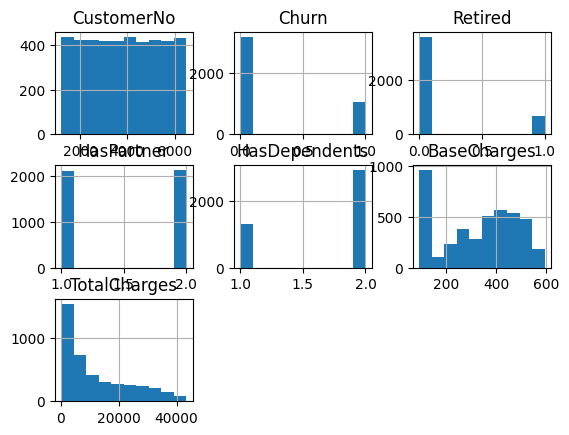

In [20]:
df_train.hist()

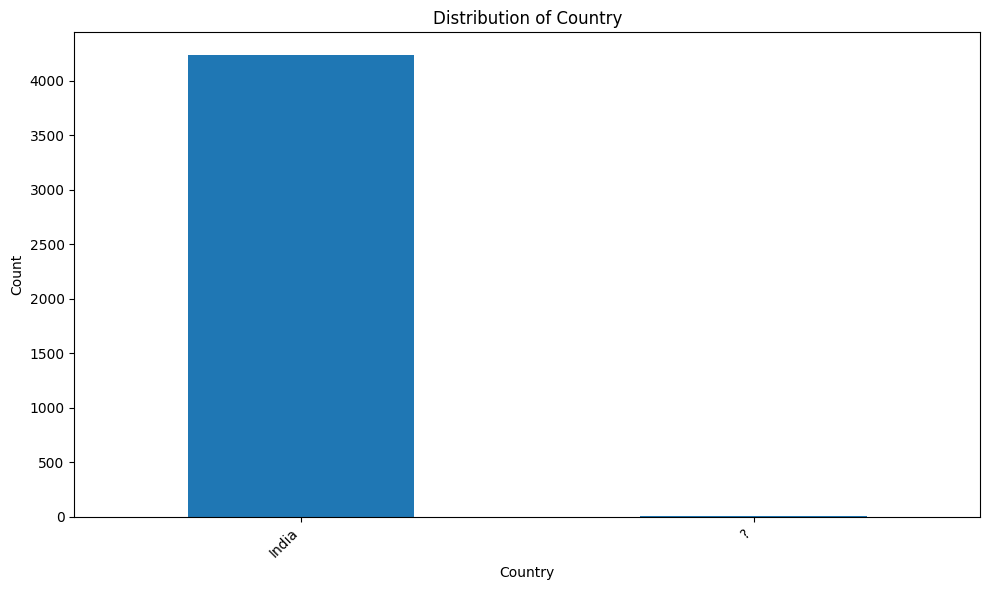

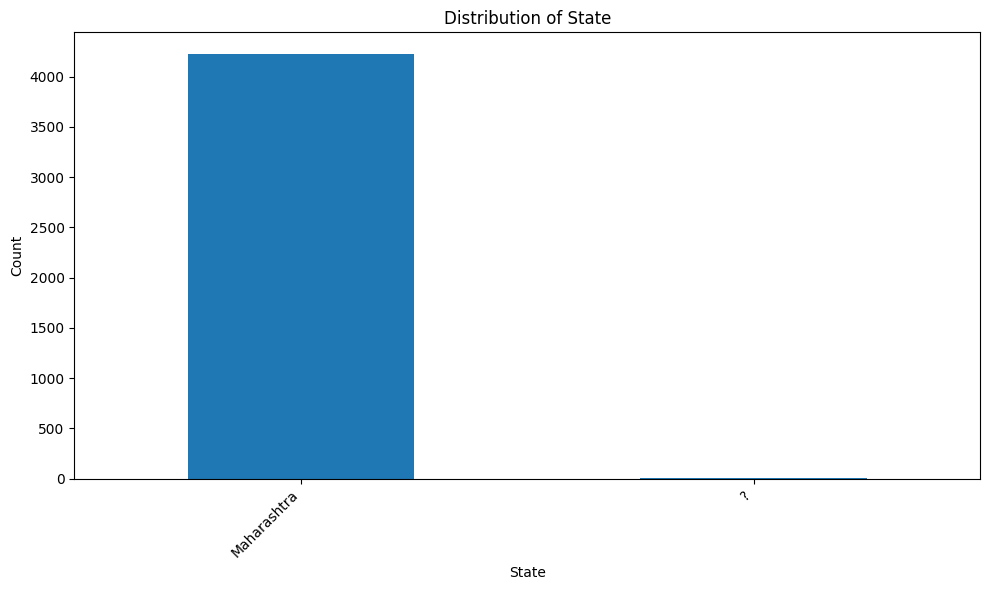

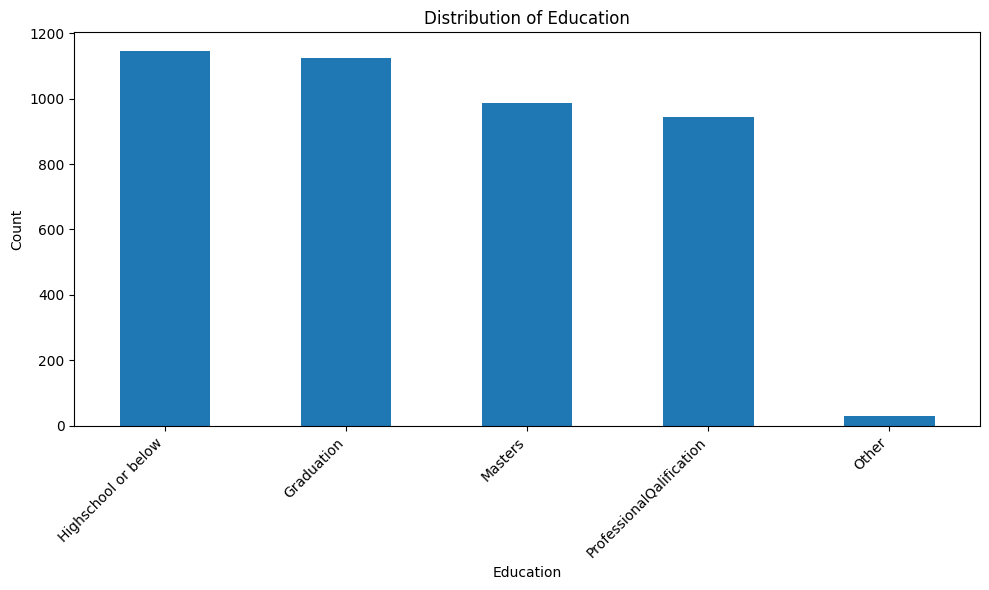

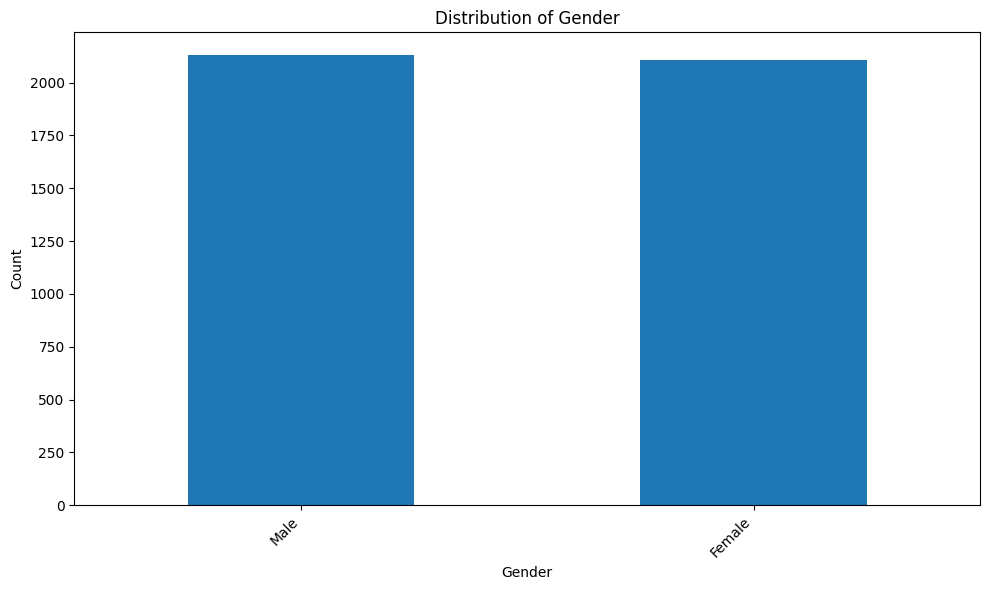

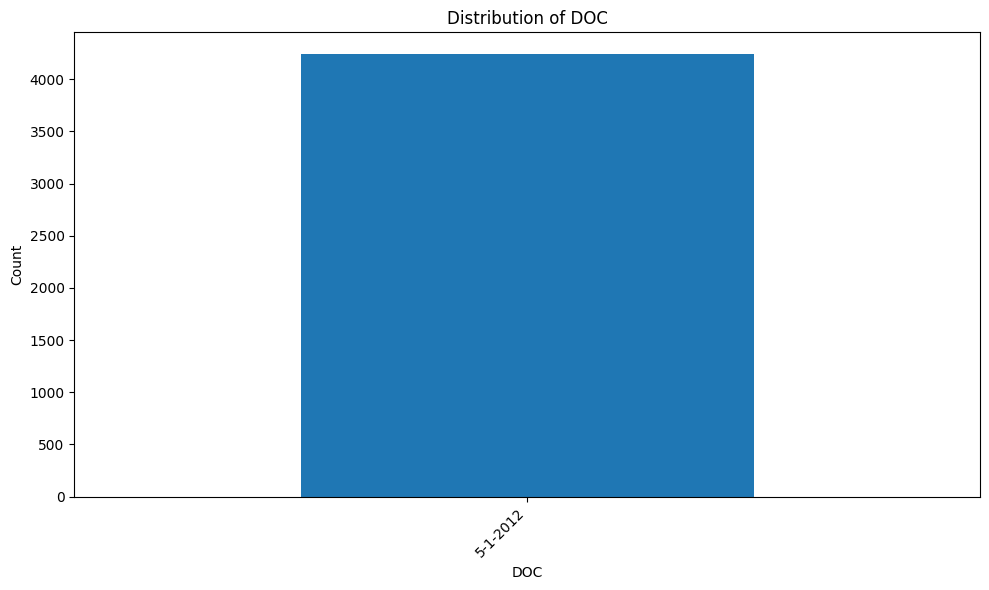

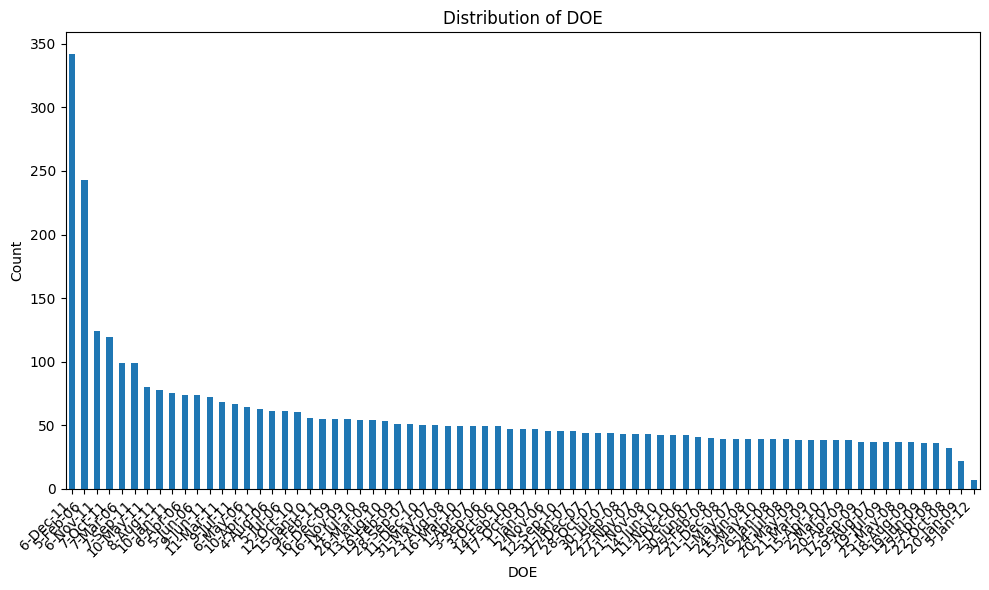

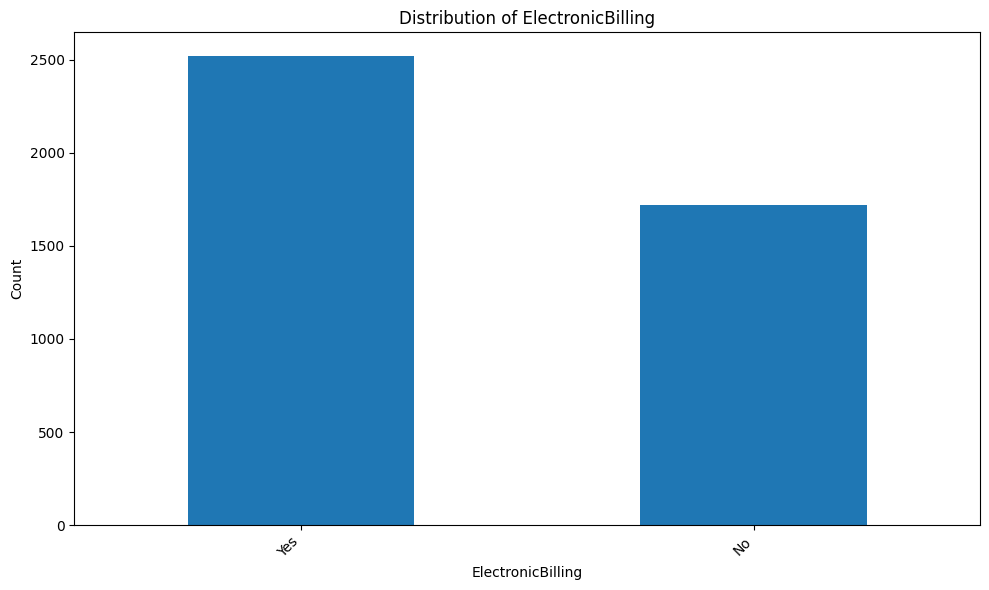

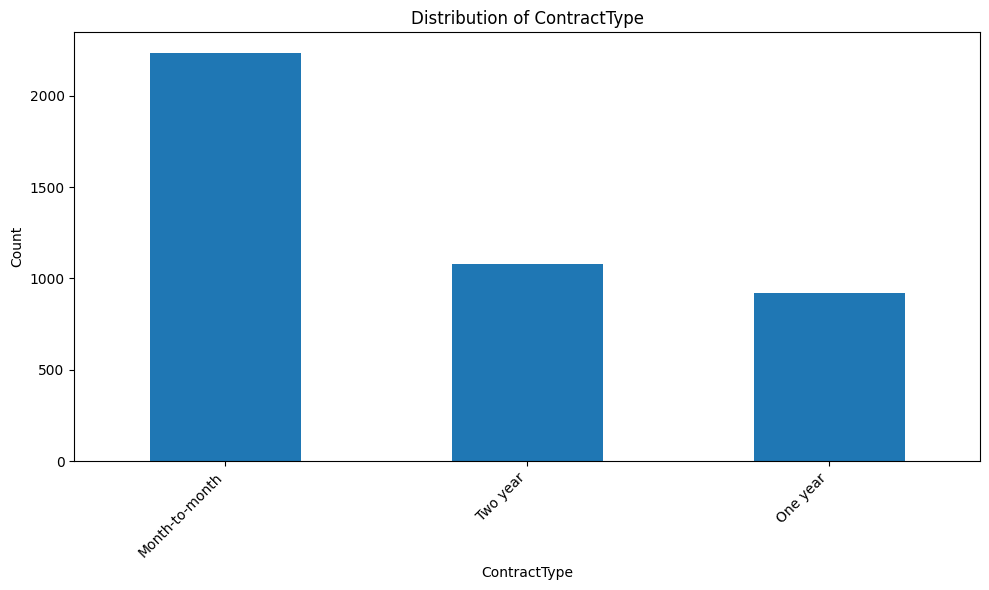

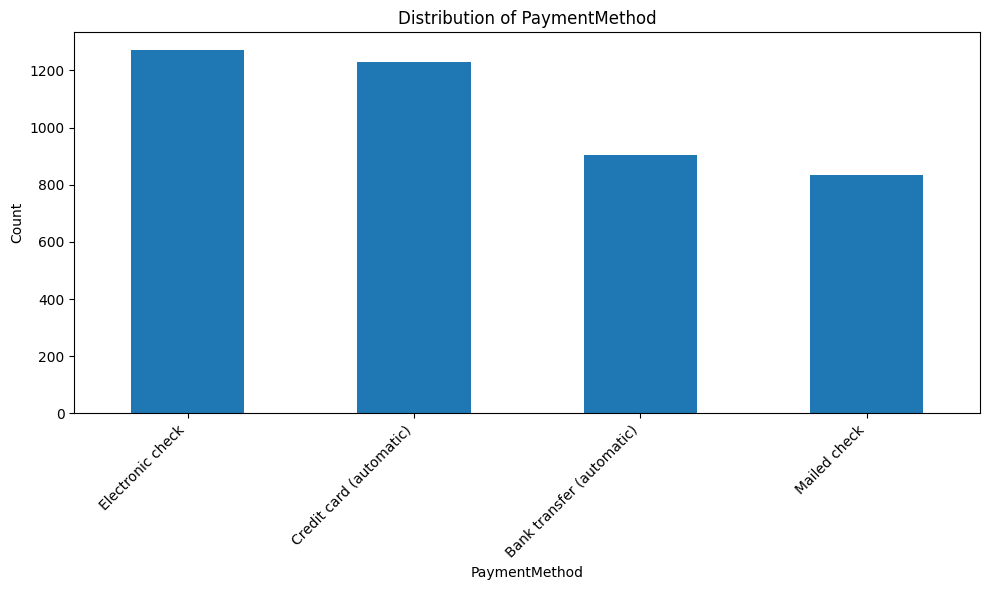

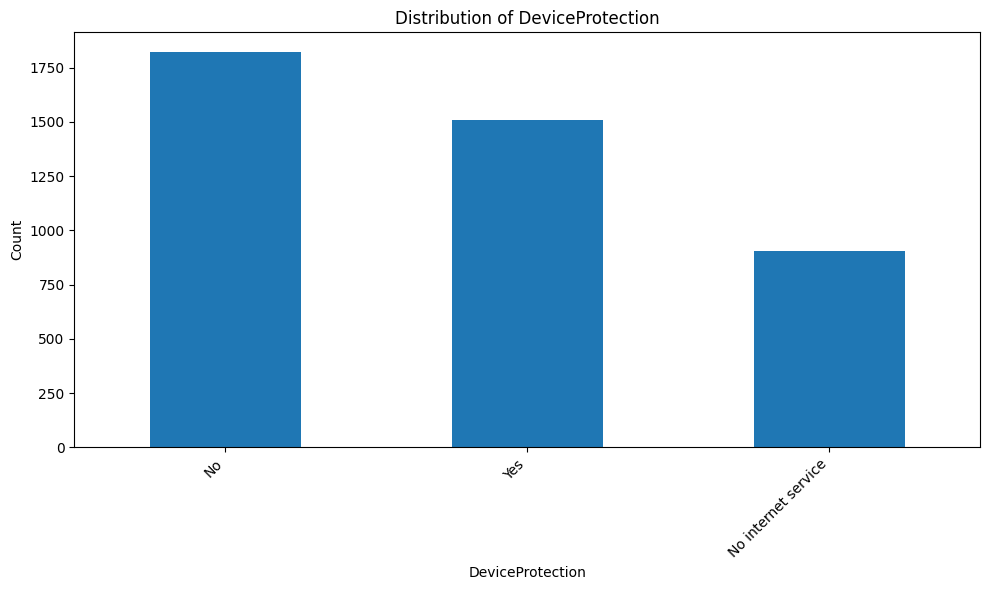

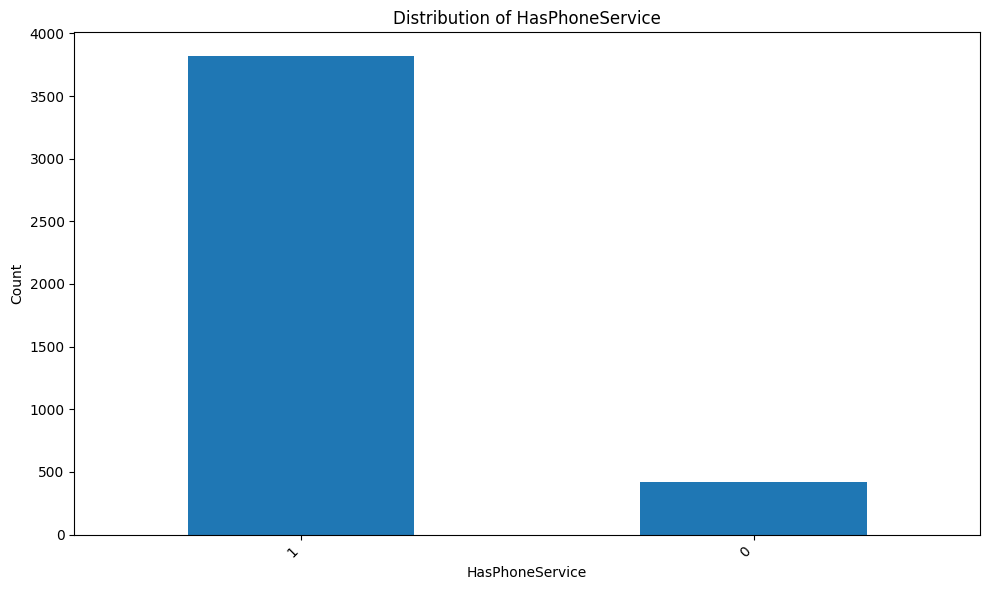

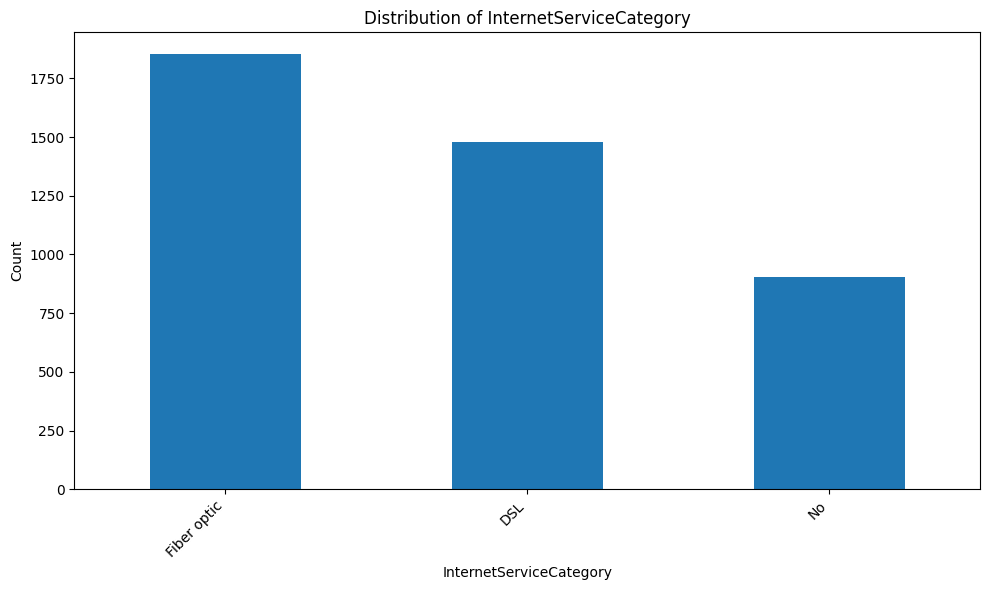

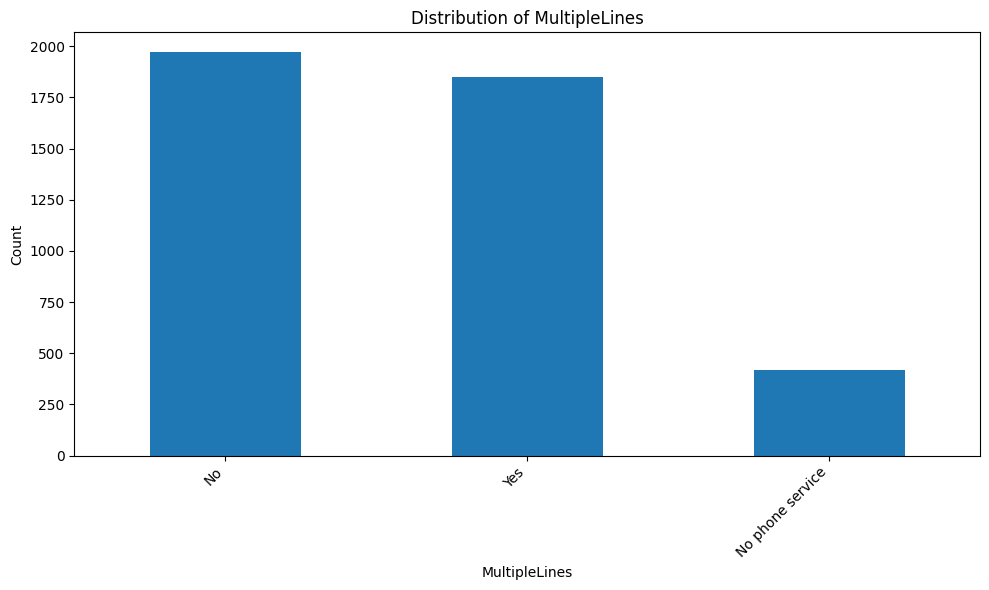

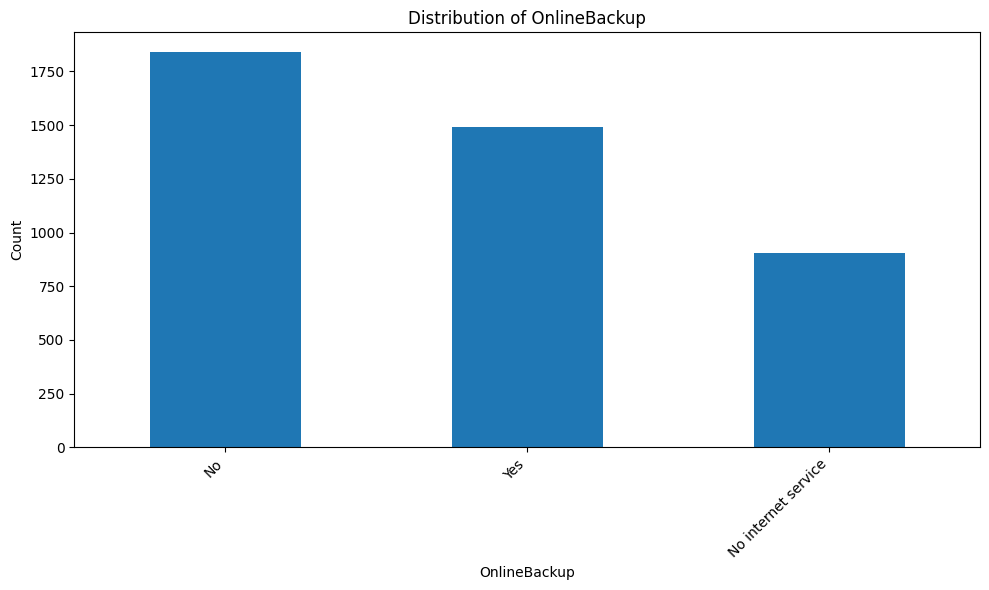

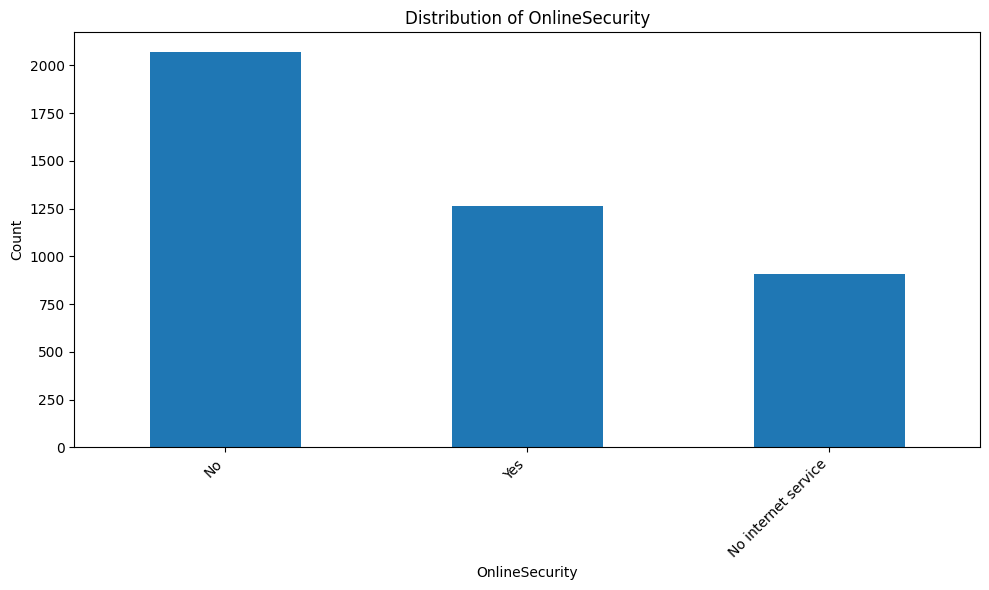

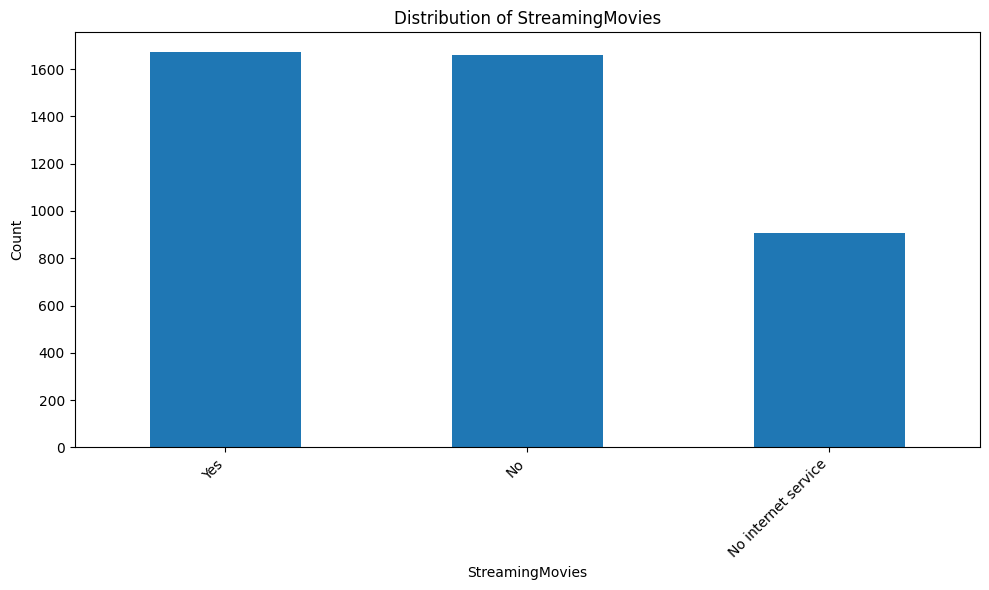

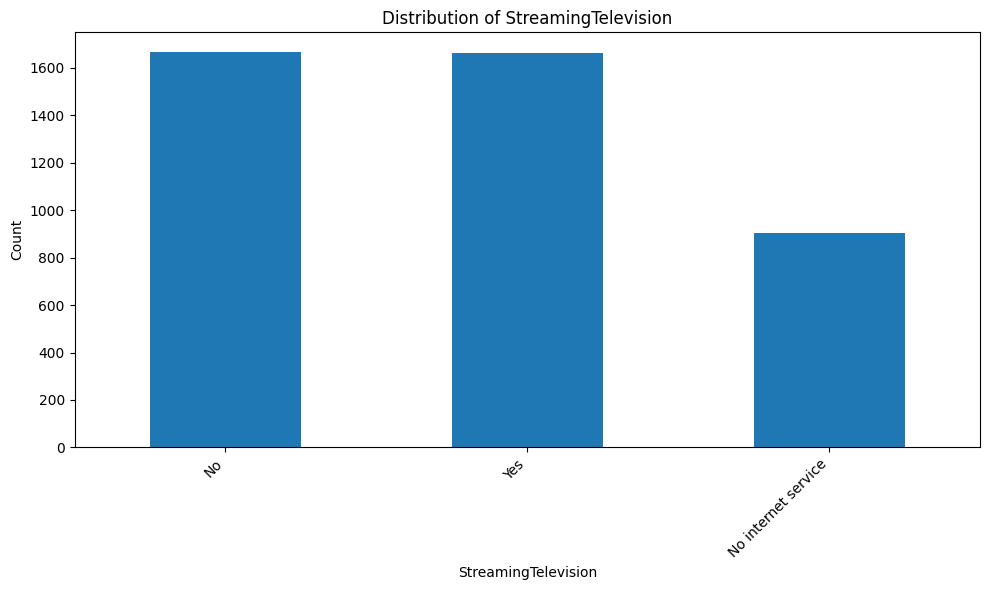

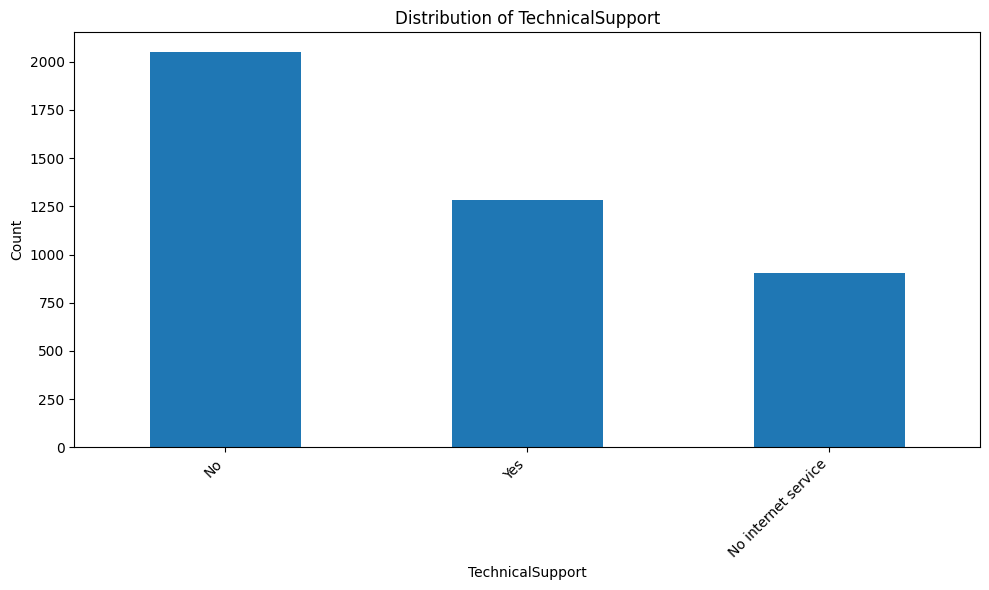

In [21]:
for column in df_train.select_dtypes(include='object').columns:
    plt.figure(figsize=(10, 6))
    df_train[column].value_counts().plot(kind='bar')
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [22]:
df_train.drop(['CustomerNo', 'Country', 'State', 'DOC', 'DOE'], axis = 1, inplace=True)
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Churn                    4238 non-null   int64  
 1   Retired                  4238 non-null   int64  
 2   HasPartner               4238 non-null   int64  
 3   HasDependents            4238 non-null   int64  
 4   Education                4229 non-null   object 
 5   Gender                   4236 non-null   object 
 6   BaseCharges              4238 non-null   float64
 7   TotalCharges             4230 non-null   float64
 8   ElectronicBilling        4238 non-null   object 
 9   ContractType             4235 non-null   object 
 10  PaymentMethod            4238 non-null   object 
 11  DeviceProtection         4238 non-null   object 
 12  HasPhoneService          4238 non-null   object 
 13  InternetServiceCategory  4238 non-null   object 
 14  MultipleLines           

In [23]:
df_train.isnull().sum()

,0
Churn,0
Retired,0
HasPartner,0
HasDependents,0
Education,9
Gender,2
BaseCharges,0
TotalCharges,8
ElectronicBilling,0
ContractType,3


In [24]:
y=df_train['Churn']
df_train.drop(['Churn'], axis=1, inplace=True)
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Retired                  4238 non-null   int64  
 1   HasPartner               4238 non-null   int64  
 2   HasDependents            4238 non-null   int64  
 3   Education                4229 non-null   object 
 4   Gender                   4236 non-null   object 
 5   BaseCharges              4238 non-null   float64
 6   TotalCharges             4230 non-null   float64
 7   ElectronicBilling        4238 non-null   object 
 8   ContractType             4235 non-null   object 
 9   PaymentMethod            4238 non-null   object 
 10  DeviceProtection         4238 non-null   object 
 11  HasPhoneService          4238 non-null   object 
 12  InternetServiceCategory  4238 non-null   object 
 13  MultipleLines            4238 non-null   object 
 14  OnlineBackup            

In [25]:
df_num=df_train[['BaseCharges', 'TotalCharges']]
df_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   BaseCharges   4238 non-null   float64
 1   TotalCharges  4230 non-null   float64
dtypes: float64(2)
memory usage: 66.3 KB


In [26]:
df_num.describe()

,BaseCharges,TotalCharges
count,4238.000000,4230.000000
mean,325.912872,11927.019622
std,151.166462,11514.252452
min,91.250000,94.250000
25%,183.500000,2286.750000
50%,352.375000,7457.625000
75%,452.000000,19966.125000
max,593.750000,43362.250000


In [63]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

median_imputer = SimpleImputer(strategy='median')

df_num_imputed = median_imputer.fit_transform(df_num)
df_num_imputed = pd.DataFrame(df_num_imputed, columns=df_num.columns)

min_max_scaler = MinMaxScaler()
df_num_scaled = min_max_scaler.fit_transform(df_num_imputed)

In [67]:
df_num_processed = pd.DataFrame(df_num_scaled, columns=df_num.columns)
df_num_processed

,BaseCharges,TotalCharges
0,0.770647,0.134643
1,0.023881,0.000208
2,0.559701,0.006431
3,0.016418,0.154416
4,0.000000,0.059611
...,...,...
4233,0.017413,0.159142
4234,0.271642,0.241460
4235,0.016418,0.115992
4236,0.666169,0.329990


In [30]:
from sklearn.impute import SimpleImputer
cat_imputer = SimpleImputer(strategy='most_frequent')

df_cat = df_train.select_dtypes(include=['object'])
df_cat['Retired'] = df_train['Retired'].astype(object)
df_cat['HasPartner'] = df_train['HasPartner'].astype(object)
df_cat['HasDependents'] = df_train['HasDependents'].astype(object)

df_cat_fill_frequent = cat_imputer.fit_transform(df_cat)
df_cat_fill_frequent = pd.DataFrame(df_cat_fill_frequent, columns=df_cat.columns)

df_cat_fill_frequent.isnull().sum()

,0
Education,0
Gender,0
ElectronicBilling,0
ContractType,0
PaymentMethod,0
DeviceProtection,0
HasPhoneService,0
InternetServiceCategory,0
MultipleLines,0
OnlineBackup,0


In [31]:
from sklearn.preprocessing import OneHotEncoder

onehot_encoder = OneHotEncoder()
df_cat_onehot = onehot_encoder.fit_transform(df_cat_fill_frequent)

onehot_encoder.categories_

[array(['Graduation', 'Highschool or below', 'Masters', 'Other',
        'ProfessionalQalification'], dtype=object),
 array(['Female', 'Male'], dtype=object),
 array(['No', 'Yes'], dtype=object),
 array(['Month-to-month', 'One year', 'Two year'], dtype=object),
 array(['Bank transfer (automatic)', 'Credit card (automatic)',
        'Electronic check', 'Mailed check'], dtype=object),
 array(['No', 'No internet service', 'Yes'], dtype=object),
 array(['0', '1'], dtype=object),
 array(['DSL', 'Fiber optic', 'No'], dtype=object),
 array(['No', 'No phone service', 'Yes'], dtype=object),
 array(['No', 'No internet service', 'Yes'], dtype=object),
 array(['No', 'No internet service', 'Yes'], dtype=object),
 array(['No', 'No internet service', 'Yes'], dtype=object),
 array(['No', 'No internet service', 'Yes'], dtype=object),
 array(['No', 'No internet service', 'Yes'], dtype=object),
 array([0, 1], dtype=object),
 array([1, 2], dtype=object),
 array([1, 2], dtype=object)]

In [32]:
column_names = onehot_encoder.get_feature_names_out()
column_names

array(['Education_Graduation', 'Education_Highschool or below',
       'Education_Masters', 'Education_Other',
       'Education_ProfessionalQalification', 'Gender_Female',
       'Gender_Male', 'ElectronicBilling_No', 'ElectronicBilling_Yes',
       'ContractType_Month-to-month', 'ContractType_One year',
       'ContractType_Two year', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'DeviceProtection_No', 'DeviceProtection_No internet service',
       'DeviceProtection_Yes', 'HasPhoneService_0', 'HasPhoneService_1',
       'InternetServiceCategory_DSL',
       'InternetServiceCategory_Fiber optic',
       'InternetServiceCategory_No', 'MultipleLines_No',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'OnlineBackup_No', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'OnlineSecurity_No',
       'OnlineSecurity_No internet service'

In [33]:
df_cat_onehot = df_cat_onehot.toarray()

In [34]:
df_cat_onehot = pd.DataFrame(df_cat_onehot, columns=column_names)
df_cat_onehot.head()

,Education_Graduation,Education_Highschool or below,Education_Masters,Education_Other,Education_ProfessionalQalification,Gender_Female,Gender_Male,ElectronicBilling_No,ElectronicBilling_Yes,ContractType_Month-to-month,...,StreamingTelevision_Yes,TechnicalSupport_No,TechnicalSupport_No internet service,TechnicalSupport_Yes,Retired_0,Retired_1,HasPartner_1,HasPartner_2,HasDependents_1,HasDependents_2
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
1,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
2,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0


In [68]:
train_encoded = pd.concat([df_num_processed, df_cat_onehot], axis=1)
train_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 50 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   BaseCharges                              4238 non-null   float64
 1   TotalCharges                             4238 non-null   float64
 2   Education_Graduation                     4238 non-null   float64
 3   Education_Highschool or below            4238 non-null   float64
 4   Education_Masters                        4238 non-null   float64
 5   Education_Other                          4238 non-null   float64
 6   Education_ProfessionalQalification       4238 non-null   float64
 7   Gender_Female                            4238 non-null   float64
 8   Gender_Male                              4238 non-null   float64
 9   ElectronicBilling_No                     4238 non-null   float64
 10  ElectronicBilling_Yes                    4238 no

In [36]:
from sklearn.tree import DecisionTreeClassifier
tree_clf1 = DecisionTreeClassifier(criterion='entropy', max_depth=3)
tree_clf1.fit(train_encoded, y)

DecisionTreeClassifier(criterion='entropy', max_depth=3)

In [37]:
df_test_no = df_test['CustomerNo']

In [38]:
df_test_no.head()

,CustomerNo
0,1203
1,1204
2,1208
3,1220
4,1221


In [39]:
df_test.drop(['CustomerNo', 'Country', 'State', 'DOC', 'DOE'], axis=1, inplace=True)

In [40]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1060 entries, 0 to 1059
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Retired                  1060 non-null   int64  
 1   HasPartner               1060 non-null   int64  
 2   HasDependents            1060 non-null   int64  
 3   Education                1059 non-null   object 
 4   Gender                   1058 non-null   object 
 5   BaseCharges              1060 non-null   float64
 6   TotalCharges             1058 non-null   float64
 7   ElectronicBilling        1060 non-null   object 
 8   ContractType             1058 non-null   object 
 9   PaymentMethod            1060 non-null   object 
 10  DeviceProtection         1060 non-null   object 
 11  HasPhoneService          1060 non-null   object 
 12  InternetServiceCategory  1060 non-null   object 
 13  MultipleLines            1060 non-null   object 
 14  OnlineBackup            

In [41]:
df_test.isnull().sum()

,0
Retired,0
HasPartner,0
HasDependents,0
Education,1
Gender,2
BaseCharges,0
TotalCharges,2
ElectronicBilling,0
ContractType,2
PaymentMethod,0


In [42]:
from sklearn.impute import SimpleImputer
median_imputer = SimpleImputer(strategy='median')

df_test_num = df_test.select_dtypes(include='float64')

df_test_num_fill_median = median_imputer.fit_transform(df_test_num)
df_test_num_fill_median = pd.DataFrame(df_test_num_fill_median, columns=df_test_num.columns)

df_test_num_fill_median.isnull().sum()

,0
BaseCharges,0
TotalCharges,0


In [43]:
df_test_num_scaled = min_max_scaler.transform(df_test_num_fill_median)
df_test_num_scaled

array([[0.61393035, 0.11839581],
       [0.46467662, 0.52378779],
       [0.61293532, 0.55089789],
       ...,
       [0.55223881, 0.09851969],
       [0.75572139, 0.67909309],
       [0.50995025, 0.18873648]])

In [44]:
df_test_num_processed = pd.DataFrame(df_test_num_scaled, columns=df_test_num.columns)
df_test_num_processed

,BaseCharges,TotalCharges
0,0.613930,0.118396
1,0.464677,0.523788
2,0.612935,0.550898
3,0.584080,0.522915
4,0.663184,0.698721
...,...,...
1055,0.014428,0.148175
1056,0.021393,0.010256
1057,0.552239,0.098520
1058,0.755721,0.679093


In [45]:
from sklearn.impute import SimpleImputer
cat_imputer = SimpleImputer(strategy='most_frequent')

df_test_cat = df_test.select_dtypes(include=['object'])
df_test_cat['Retired'] = df_test['Retired'].astype(object)
df_test_cat['HasPartner'] = df_test['HasPartner'].astype(object)
df_test_cat['HasDependents'] = df_test['HasDependents'].astype(object)

df_test_cat_fill_frequent = cat_imputer.fit_transform(df_test_cat)
df_test_cat_fill_frequent = pd.DataFrame(df_test_cat_fill_frequent, columns=df_test_cat.columns)

df_test_cat_fill_frequent.isnull().sum()

,0
Education,0
Gender,0
ElectronicBilling,0
ContractType,0
PaymentMethod,0
DeviceProtection,0
HasPhoneService,0
InternetServiceCategory,0
MultipleLines,0
OnlineBackup,0


In [46]:
df_test_cat_onehot = onehot_encoder.transform(df_test_cat_fill_frequent).toarray()

df_test_cat_onehot = pd.DataFrame(df_test_cat_onehot, columns=column_names)

In [47]:
df_test_cat_onehot.head()

,Education_Graduation,Education_Highschool or below,Education_Masters,Education_Other,Education_ProfessionalQalification,Gender_Female,Gender_Male,ElectronicBilling_No,ElectronicBilling_Yes,ContractType_Month-to-month,...,StreamingTelevision_Yes,TechnicalSupport_No,TechnicalSupport_No internet service,TechnicalSupport_Yes,Retired_0,Retired_1,HasPartner_1,HasPartner_2,HasDependents_1,HasDependents_2
0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
1,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
2,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0
3,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0


In [48]:
test_encoded = pd.concat([df_test_num_processed, df_test_cat_onehot], axis=1)
test_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1060 entries, 0 to 1059
Data columns (total 50 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   BaseCharges                              1060 non-null   float64
 1   TotalCharges                             1060 non-null   float64
 2   Education_Graduation                     1060 non-null   float64
 3   Education_Highschool or below            1060 non-null   float64
 4   Education_Masters                        1060 non-null   float64
 5   Education_Other                          1060 non-null   float64
 6   Education_ProfessionalQalification       1060 non-null   float64
 7   Gender_Female                            1060 non-null   float64
 8   Gender_Male                              1060 non-null   float64
 9   ElectronicBilling_No                     1060 non-null   float64
 10  ElectronicBilling_Yes                    1060 no

In [49]:
y_hat = tree_clf1.predict(test_encoded)
y_hat.shape

(1060,)

In [50]:
y_hat = y_hat.astype(int)
y_hat

array([1, 0, 0, ..., 1, 0, 0])

In [51]:
tree1_onehot_submit = pd.DataFrame({
    'CustomerNo': df_test_no,
    'Churn': y_hat,
})

In [52]:
tree1_onehot_submit.head()

,CustomerNo,Churn
0,1203,1
1,1204,0
2,1208,0
3,1220,0
4,1221,0


In [53]:
tree1_onehot_submit.to_csv(f'{output_dir}/churn_tree_onehot_submit1.csv', index=False)

In [54]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

rf_clf.fit(train_encoded, y)

RandomForestClassifier(random_state=42)

In [55]:
y_hat_rf = rf_clf.predict(test_encoded)

y_hat_rf = y_hat_rf.astype(int)

print(y_hat_rf[:10])

[0 0 0 0 0 0 0 1 1 0]


In [56]:
rf_submit = pd.DataFrame({
    'CustomerNo': df_test_no,
    'Churn': y_hat_rf,
})

display(rf_submit.head())

rf_submit.to_csv(f'{output_dir}/churn_randomforest_submit.csv', index=False)
print(f"Submission file saved to {output_dir}/churn_randomforest_submit.csv")

,CustomerNo,Churn
0,1203,0
1,1204,0
2,1208,0
3,1220,0
4,1221,0


Submission file saved to /content/drive/My Drive/Colab Notebooks/output//churn_randomforest_submit.csv


In [57]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_clf_tuned = RandomForestClassifier(random_state=42)

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=rf_clf_tuned,
    param_grid=param_grid,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(train_encoded, y)

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score: ", grid_search.best_score_)

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best parameters found:  {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation score:  0.8150077821817776


In [58]:
best_rf_model = grid_search.best_estimator_

y_hat_rf_tuned = best_rf_model.predict(test_encoded)

y_hat_rf_tuned = y_hat_rf_tuned.astype(int)

print(y_hat_rf_tuned[:10])

[0 0 0 0 0 0 0 1 1 0]


In [59]:
rf_tuned_submit = pd.DataFrame({
    'CustomerNo': df_test_no,
    'Churn': y_hat_rf_tuned,
})

display(rf_tuned_submit.head())

rf_tuned_submit.to_csv(f'{output_dir}/churn_randomforest_tuned_submit.csv', index=False)
print(f"Submission file saved to {output_dir}/churn_randomforest_tuned_submit.csv")

,CustomerNo,Churn
0,1203,0
1,1204,0
2,1208,0
3,1220,0
4,1221,0


Submission file saved to /content/drive/My Drive/Colab Notebooks/output//churn_randomforest_tuned_submit.csv


In [69]:
from sklearn.linear_model import LogisticRegression

log_reg_clf = LogisticRegression(solver='liblinear', penalty='l1', C=1.0, random_state=42)

log_reg_clf.fit(train_encoded, y)

LogisticRegression(penalty='l1', random_state=42, solver='liblinear')

In [70]:
y_hat_log_reg = log_reg_clf.predict(test_encoded)

y_hat_log_reg = y_hat_log_reg.astype(int)

print(y_hat_log_reg[:10])

[0 0 0 0 0 0 0 1 1 0]


In [71]:
log_reg_submit = pd.DataFrame({
    'CustomerNo': df_test_no,
    'Churn': y_hat_log_reg,
})

display(log_reg_submit.head())

log_reg_submit.to_csv(f'{output_dir}/churn_logistic_regression_submit.csv', index=False)
print(f"Submission file saved to {output_dir}/churn_logistic_regression_submit.csv")

,CustomerNo,Churn
0,1203,0
1,1204,0
2,1208,0
3,1220,0
4,1221,0


Submission file saved to /content/drive/My Drive/Colab Notebooks/output//churn_logistic_regression_submit.csv
